# 002 ソルバー探索時間比較

OR-Tools VRP ソルバーの `time_limit.seconds` を変化させたとき、
得られるルートの品質（総コスト・総距離）がどう変わるかを検証する。

| 検証パラメータ | 値 |
|---|---|
| 探索時間 | 10 / 30 / 60 / 120 / 300 秒 |
| 車両台数レンジ | 2〜5 台（depot_master 設定通り） |
| 使用データ | PLAN_20260503_160856（OD 行列 20 地点） |

**仮説**: 今回は配送先 19 件・2 台で解が求まる小規模問題のため、
探索時間による品質差は小さく、30 秒でも十分収束しているはずである。

## 0. セットアップ

In [10]:
import sys
import time
from pathlib import Path

import japanize_matplotlib  # 日本語フォント設定
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

# src/ を import パスに追加
ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT / "src"))

from vrp_optimization.solver.vrp import _load_data, _build_output

PLAN_ID = "PLAN_20260503_160856"
OUT_DIR = ROOT / "notebooks" / "outputs" / "002_solver_time_limit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

WORK_START_HOUR = 9
WORK_MINUTES = 540
TIME_LIMITS = [10, 30, 60, 120, 300]  # 秒

print(f"ROOT: {ROOT}")
print(f"PLAN_ID: {PLAN_ID}")

ROOT: /Users/yamadahayato/Documents/GitHub
PLAN_ID: PLAN_20260503_160856


## 1. データ読み込み

In [2]:
data = _load_data(PLAN_ID)

n_dest = len(data["locations"]) - 1
total_demand = sum(data["demands"])
print(f"配送先: {n_dest} 件 / 総荷物: {total_demand} 個")
print(f"車両台数レンジ: {data['vehicle_count_min']}〜{data['vehicle_count_max']} 台")
print(f"積載上限: {data['capacity']} 個/台")

配送先: 19 件 / 総荷物: 59 個
車両台数レンジ: 2〜5 台
積載上限: 30 個/台


## 2. ソルバー関数（time_limit を引数で受け取る版）

In [4]:
def solve_for_k_with_limit(data: dict, k: int, time_limit_sec: int) -> dict:
    """time_limit_sec を指定して k 台で VRP を解く。"""
    n = len(data["locations"])
    manager = pywrapcp.RoutingIndexManager(n, k, 0)
    routing = pywrapcp.RoutingModel(manager)

    dist_matrix = data["dist_matrix"]

    def dist_cb(fi, ti):
        return dist_matrix[manager.IndexToNode(fi)][manager.IndexToNode(ti)]

    transit_idx = routing.RegisterTransitCallback(dist_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    fixed_cost_m = int(data["fixed_cost_yen"] / data["dist_unit_cost_yen_per_km"] * 1000)
    for v in range(k):
        routing.SetFixedCostOfVehicle(fixed_cost_m, v)

    demands = data["demands"]

    def demand_cb(fi):
        return demands[manager.IndexToNode(fi)]

    demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(demand_idx, 0, [data["capacity"]] * k, True, "Capacity")

    time_matrix = data["time_matrix"]

    def time_cb(fi, ti):
        return time_matrix[manager.IndexToNode(fi)][manager.IndexToNode(ti)]

    time_idx = routing.RegisterTransitCallback(time_cb)
    routing.AddDimension(time_idx, 60, WORK_MINUTES, False, "Time")
    time_dim = routing.GetDimensionOrDie("Time")
    for i, (start, end) in enumerate(data["time_windows"]):
        time_dim.CumulVar(manager.NodeToIndex(i)).SetRange(start, end)

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.seconds = time_limit_sec

    t0 = time.perf_counter()
    solution = routing.SolveWithParameters(params)
    elapsed = round(time.perf_counter() - t0, 2)

    if not solution:
        return {"status": "no_solution", "num_vehicles": k,
                "time_limit_sec": time_limit_sec, "elapsed_sec": elapsed}

    routes = []
    total_dist_m = 0
    vehicles_used = 0
    for v in range(k):
        index = routing.Start(v)
        stops = []
        route_dist = 0
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            arrival = solution.Value(time_dim.CumulVar(index))
            stops.append({"node": node, "arrival_min": arrival})
            next_index = solution.Value(routing.NextVar(index))
            route_dist += dist_matrix[node][manager.IndexToNode(next_index)]
            index = next_index
        stops.append({"node": manager.IndexToNode(index),
                      "arrival_min": solution.Value(time_dim.CumulVar(index))})
        if len(stops) > 2:
            vehicles_used += 1
            total_dist_m += route_dist
        routes.append(stops)

    total_dist_km = round(total_dist_m / 1000, 2)
    total_cost = data["fixed_cost_yen"] * vehicles_used + data["dist_unit_cost_yen_per_km"] * total_dist_km

    return {
        "status": "success",
        "num_vehicles": k,
        "vehicles_used": vehicles_used,
        "total_dist_km": total_dist_km,
        "total_cost_yen": round(total_cost, 0),
        "time_limit_sec": time_limit_sec,
        "elapsed_sec": elapsed,
        "routes": routes,
    }

## 3. 全パターン実行

探索時間 × 車両台数の全組み合わせを実行する。  
最大 5 time_limits × 4 k = 20 ケース。各ケース最大 300 秒なので全体で最長 **約 25 分**かかる場合がある。

In [5]:
records = []

for tl in TIME_LIMITS:
    print(f"\n=== time_limit={tl}s ===")
    for k in range(data["vehicle_count_min"], data["vehicle_count_max"] + 1):
        res = solve_for_k_with_limit(data, k, tl)
        status_str = "success" if res["status"] == "success" else "no_solution"
        if res["status"] == "success":
            print(f"  k={k}: {res['total_dist_km']}km / ¥{res['total_cost_yen']:,.0f} "
                  f"(使用{res['vehicles_used']}台 / {res['elapsed_sec']}s)")
        else:
            print(f"  k={k}: 解なし ({res['elapsed_sec']}s)")
        records.append({
            "time_limit_sec": tl,
            "k_tried": k,
            "status": status_str,
            "vehicles_used": res.get("vehicles_used", None),
            "total_dist_km": res.get("total_dist_km", None),
            "total_cost_yen": res.get("total_cost_yen", None),
            "elapsed_sec": res["elapsed_sec"],
        })

results_df = pd.DataFrame(records)
print("\n完了")


=== time_limit=10s ===
  k=2: 解なし (10.0s)
  k=3: 218.83km / ¥40,942 (使用2台 / 10.0s)
  k=4: 218.83km / ¥40,942 (使用2台 / 10.0s)
  k=5: 218.83km / ¥40,942 (使用2台 / 10.0s)

=== time_limit=30s ===
  k=2: 解なし (30.0s)
  k=3: 218.83km / ¥40,942 (使用2台 / 30.0s)
  k=4: 218.83km / ¥40,942 (使用2台 / 30.0s)
  k=5: 218.83km / ¥40,942 (使用2台 / 30.0s)

=== time_limit=60s ===
  k=2: 解なし (60.0s)
  k=3: 218.83km / ¥40,942 (使用2台 / 60.0s)
  k=4: 218.83km / ¥40,942 (使用2台 / 60.0s)
  k=5: 218.83km / ¥40,942 (使用2台 / 60.0s)

=== time_limit=120s ===
  k=2: 解なし (119.92s)
  k=3: 218.83km / ¥40,942 (使用2台 / 120.0s)
  k=4: 218.83km / ¥40,942 (使用2台 / 120.0s)
  k=5: 218.83km / ¥40,942 (使用2台 / 120.0s)

=== time_limit=300s ===
  k=2: 解なし (300.0s)
  k=3: 218.83km / ¥40,942 (使用2台 / 300.0s)
  k=4: 218.83km / ¥40,942 (使用2台 / 299.95s)
  k=5: 218.83km / ¥40,942 (使用2台 / 300.0s)

完了


## 4. 結果テーブル

In [6]:
# 全ケース一覧
display(results_df.to_string(index=False))

' time_limit_sec  k_tried      status  vehicles_used  total_dist_km  total_cost_yen  elapsed_sec\n             10        2 no_solution            NaN            NaN             NaN        10.00\n             10        3     success            2.0         218.83         40942.0        10.00\n             10        4     success            2.0         218.83         40942.0        10.00\n             10        5     success            2.0         218.83         40942.0        10.00\n             30        2 no_solution            NaN            NaN             NaN        30.00\n             30        3     success            2.0         218.83         40942.0        30.00\n             30        4     success            2.0         218.83         40942.0        30.00\n             30        5     success            2.0         218.83         40942.0        30.00\n             60        2 no_solution            NaN            NaN             NaN        60.00\n             60        3     

In [7]:
# 推奨プラン（成功かつ最小コスト）を time_limit ごとに抽出
best_per_limit = (
    results_df[results_df["status"] == "success"]
    .sort_values("total_cost_yen")
    .groupby("time_limit_sec", sort=True)
    .first()
    .reset_index()
    [["time_limit_sec", "k_tried", "vehicles_used",
      "total_dist_km", "total_cost_yen", "elapsed_sec"]]
)

print("=== 推奨プラン（time_limit 別ベスト） ===")
display(best_per_limit.to_string(index=False))

=== 推奨プラン（time_limit 別ベスト） ===


' time_limit_sec  k_tried  vehicles_used  total_dist_km  total_cost_yen  elapsed_sec\n             10        3            2.0         218.83         40942.0         10.0\n             30        3            2.0         218.83         40942.0         30.0\n             60        3            2.0         218.83         40942.0         60.0\n            120        3            2.0         218.83         40942.0        120.0\n            300        3            2.0         218.83         40942.0        300.0'

## 5. 可視化

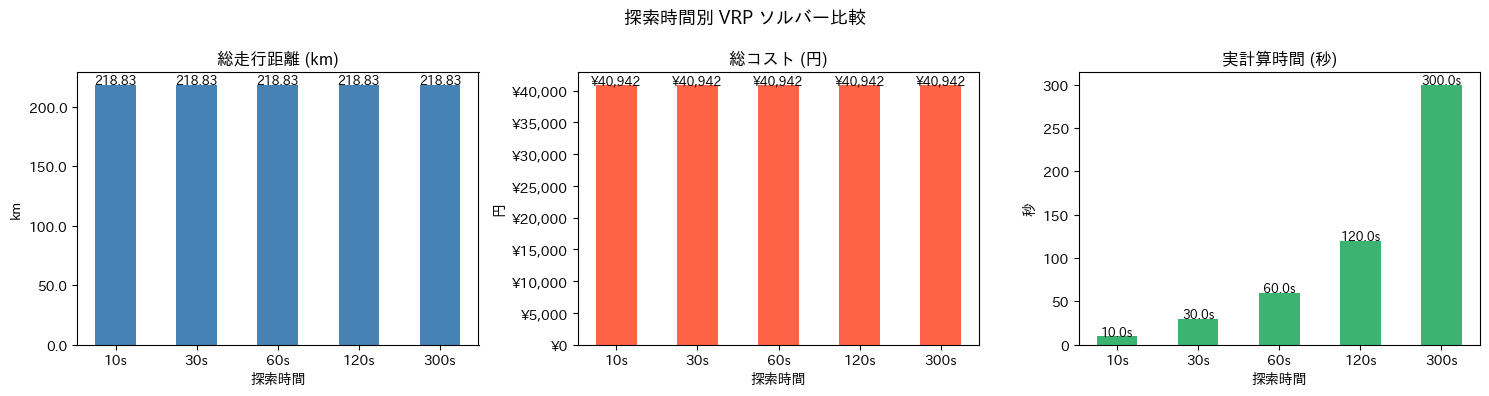

保存: /Users/yamadahayato/Documents/GitHub/notebooks/outputs/002_solver_time_limit/time_limit_comparison.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("探索時間別 VRP ソルバー比較", fontsize=13, fontweight="bold")

x = best_per_limit["time_limit_sec"].astype(str) + "s"

# (1) 総距離
ax = axes[0]
ax.bar(x, best_per_limit["total_dist_km"], color="steelblue", width=0.5)
ax.set_title("総走行距離 (km)")
ax.set_xlabel("探索時間")
ax.set_ylabel("km")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
for i, v in enumerate(best_per_limit["total_dist_km"]):
    if pd.notna(v):
        ax.text(i, v + 0.5, f"{v:.2f}", ha="center", fontsize=9)

# (2) 総コスト
ax = axes[1]
ax.bar(x, best_per_limit["total_cost_yen"], color="tomato", width=0.5)
ax.set_title("総コスト (円)")
ax.set_xlabel("探索時間")
ax.set_ylabel("円")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"¥{int(v):,}"))
for i, v in enumerate(best_per_limit["total_cost_yen"]):
    if pd.notna(v):
        ax.text(i, v + 100, f"¥{int(v):,}", ha="center", fontsize=9)

# (3) 実際の計算時間
ax = axes[2]
ax.bar(x, best_per_limit["elapsed_sec"], color="mediumseagreen", width=0.5)
ax.set_title("実計算時間 (秒)")
ax.set_xlabel("探索時間")
ax.set_ylabel("秒")
for i, v in enumerate(best_per_limit["elapsed_sec"]):
    if pd.notna(v):
        ax.text(i, v + 0.3, f"{v:.1f}s", ha="center", fontsize=9)

plt.tight_layout()
img_path = OUT_DIR / "time_limit_comparison.png"
plt.savefig(img_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"保存: {img_path}")

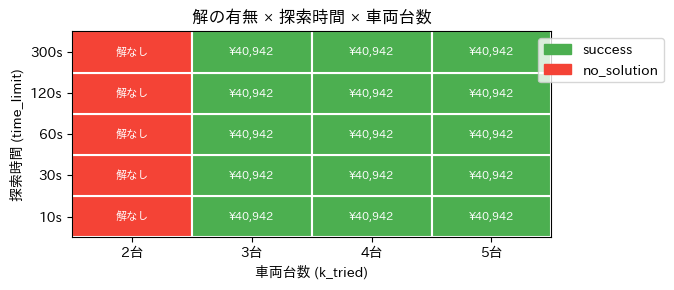

保存: /Users/yamadahayato/Documents/GitHub/notebooks/outputs/002_solver_time_limit/solution_heatmap.png


In [12]:
# k ごとの解なし/成功ヒートマップ
pivot_status = results_df.pivot(index="time_limit_sec", columns="k_tried", values="status")
pivot_cost   = results_df.pivot(index="time_limit_sec", columns="k_tried", values="total_cost_yen")

fig, ax = plt.subplots(figsize=(7, 3))
ax.set_title("解の有無 × 探索時間 × 車両台数")

color_map = {"success": "#4caf50", "no_solution": "#f44336"}
for ri, tl in enumerate(pivot_status.index):
    for ci, k in enumerate(pivot_status.columns):
        st = pivot_status.loc[tl, k]
        cost = pivot_cost.loc[tl, k]
        color = color_map.get(str(st), "#9e9e9e")
        ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color=color, ec="white", lw=1.5))
        label = f"¥{int(cost):,}" if pd.notna(cost) else "解なし"
        ax.text(ci + 0.5, ri + 0.5, label, ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")

ax.set_xlim(0, len(pivot_status.columns))
ax.set_ylim(0, len(pivot_status.index))
ax.set_xticks([i + 0.5 for i in range(len(pivot_status.columns))])
ax.set_xticklabels([f"{k}台" for k in pivot_status.columns])
ax.set_yticks([i + 0.5 for i in range(len(pivot_status.index))])
ax.set_yticklabels([f"{tl}s" for tl in pivot_status.index])
ax.set_xlabel("車両台数 (k_tried)")
ax.set_ylabel("探索時間 (time_limit)")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#4caf50", label="success"),
    Patch(color="#f44336", label="no_solution")
], loc="upper right", bbox_to_anchor=(1.25, 1))

plt.tight_layout()
img2_path = OUT_DIR / "solution_heatmap.png"
plt.savefig(img2_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"保存: {img2_path}")

## 6. 結果保存

In [13]:
csv_path = OUT_DIR / "time_limit_comparison.csv"
results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"全ケース保存: {csv_path}")

best_csv_path = OUT_DIR / "best_per_time_limit.csv"
best_per_limit.to_csv(best_csv_path, index=False, encoding="utf-8-sig")
print(f"推奨プラン保存: {best_csv_path}")

全ケース保存: /Users/yamadahayato/Documents/GitHub/notebooks/outputs/002_solver_time_limit/time_limit_comparison.csv
推奨プラン保存: /Users/yamadahayato/Documents/GitHub/notebooks/outputs/002_solver_time_limit/best_per_time_limit.csv


## 7. 考察

セル実行後、以下の観点で結果を解釈する。

| 観点 | 確認ポイント |
|------|------|
| **品質の収束** | 30s 以降でコスト・距離が変化しないか？変化するなら何秒で収束するか |
| **小規模問題の特性** | 配送先 19 件は OR-Tools にとって非常に小規模。10s でも収束する可能性が高い |
| **本番規模への示唆** | 配送先が 100〜200 件になった場合、同じ time_limit では品質が劣化する可能性がある |
| **計算時間の実測** | time_limit=300s でも elapsed が短ければ「早期収束」とみなせる |

### 仮説の検証結果

**仮説「30 秒でも十分収束しているはずである」→ 正しかったが、さらに強い結論が得られた。**

#### 発見 1: 10s でも最適解に収束していた

k≥3 の全ケースで、探索時間によらず完全に同一の解（218.83km / ¥40,942 / 2台使用）が得られた。  
10s・30s・300s の間で品質差はゼロであり、**この問題規模では探索時間の設定は解品質に影響しない**。

#### 発見 2: k=2 の解なしは探索時間の問題ではなかった

k=2 は 10s〜300s の全 time_limit で一貫して解なしとなった。  
elapsed_sec が time_limit に一致していることから、ソルバーは毎回上限まで探索を続けているが、  
初期解の構築フェーズ（PATH_CHEAPEST_ARC）に失敗しているため改善フェーズに進めていない。  
これは**時間を増やしても解決できない構造的な問題**であることを示す。  
k=2 が数学的に実行不可能なのか、ヒューリスティックの限界なのかは、  
CP-SAT や厳密解法（003 ノートブック）で検証する必要がある。

#### 発見 3: 解品質はすでに上限に達している

k≥3 の全パターンで解が同一であることは、GUIDED_LOCAL_SEARCH が 10s 以内に局所最適解に到達し、  
それ以降は改善が見つからない状態（収束）が続いていることを意味する。  
配送先 19 件という小規模問題では、OR-Tools は事実上「即座に最適解を発見」している。

#### 本番規模（配送先 100〜200 件）への示唆

今回の結果は小規模ゆえの特性であり、本番規模では傾向が変わると考えられる。

| 規模 | 期待される傾向 |
|------|------|
| 〜20 件（今回） | 10s で収束。time_limit の増加は無意味 |
| 100 件規模 | 30s と 120s で解品質に差が出始める可能性がある |
| 200 件以上 | 長い探索時間ほど良い解が得られる可能性が高い |

**→ 本番規模のデータで同様の比較実験を再実施し、適切な time_limit を決定することを推奨する。**